# Machine Learning para Engenharia de Dados — Notebook Prático

**Instituição:** Universidade de Fortaleza (UNIFOR)
**Curso:** Pós-Graduação Lato Sensu - Especialização em Engenharia de Dados
**Professor:** Cassio Pinheiro
**LinkedIn:** https://www.linkedin.com/in/cassio-pinheiro-9baa7939/
**Carga horária:** 24h
**Datas:** 14, 15, 21, 22 e 23 de maio de 2026

---

## Como usar este notebook

1. Execute todas as células do **Setup** e do **Carregamento do Dataset** primeiro.
2. Cada seção corresponde a um **encontro** do plano de ensino, na mesma ordem.
3. O dataset sintético é **determinístico** (seed=42) — todos os alunos chegam ao mesmo resultado.
4. As células de markdown trazem teoria condensada; o aprofundamento está no documento `.md` correspondente.

## Projeto fio condutor: Detecção de Fraudes em Transações Financeiras

Dataset sintético determinístico com 10.000 transações simulando um sistema de pagamentos, já disponível em `dataset/transacoes.csv`. Variáveis: valor, hora, merchant_category, device_type, hist_compras_30d, e a label binária `fraude`.


## Setup — Imports e configuração

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Determinismo: tudo reproduzível
SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
print("Setup OK. Versões:")
print(f"  numpy  {np.__version__}")
print(f"  pandas {pd.__version__}")


Setup OK. Versões:
  numpy  2.2.6
  pandas 2.3.3


## Carregamento do dataset

In [17]:
# ----------------------------------------------------------------------
# Carregamento do dataset — Transações Financeiras
# ----------------------------------------------------------------------
# O dataset sintético (determinístico, seed=42) já está versionado em
# ./dataset/transacoes.csv — basta carregá-lo.
from pathlib import Path

DATASET_PATH = Path("dataset") / "transacoes.csv"
df = pd.read_csv(DATASET_PATH)

print(f"Dataset carregado: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print(f"Taxa de fraude: {df['fraude'].mean():.2%}")
df.head()


Dataset carregado: 10,000 linhas × 8 colunas
Taxa de fraude: 1.57%


,transacao_id,valor,hora,merchant_category,device_type,hist_compras_30d,tempo_conta_dias,fraude
0,1,125.86,21,alimentacao,mobile,61,1677,0
1,2,28.67,18,saude,desktop,18,2168,0
2,3,205.51,16,vestuario,desktop,59,889,0
3,4,253.31,5,vestuario,mobile,3,2995,0
4,5,10.53,14,servicos,desktop,63,1331,0


---

# Módulo 1 — Fundamentos e Preparação (Hoje & Amanhã)

## Encontro 1
**Data:** 14/05  •  **Horário:** 19:00 às 22:30

**Tópicos cobertos:**
- Visão geral de ML na Engenharia de Dados.
- Ciclo de vida do projeto (CRISP-ML(Q)).
- Análise Exploratória de Dados (EDA) focada em modelagem.

> 📖 **No documento `.md`:** seção *Encontro 1* contém a fundamentação teórica detalhada.

> 🎯 **Nos slides:** veja os slides do Encontro 1 para a apresentação em sala.

### Visão geral de ML na Engenharia de Dados.

In [18]:
# [E1T1] Visão geral de ML na Engenharia de Dados
# Tópico sem receita específica no catálogo — explorando o dataset.
df.describe(include='all').T.head(10)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
transacao_id,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
valor,10000.0,NaN,NaN,NaN,164.542037,255.720773,0.72,42.73,88.725,184.0075,7543.24
hora,10000.0,NaN,NaN,NaN,11.6279,6.903203,0.0,6.0,12.0,18.0,23.0
merchant_category,10000,6,alimentacao,3001,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_type,10000,4,mobile,5488,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hist_compras_30d,10000.0,NaN,NaN,NaN,39.7901,23.111786,0.0,20.0,40.0,60.0,79.0
tempo_conta_dias,10000.0,NaN,NaN,NaN,1505.2484,867.71658,1.0,757.0,1510.0,2259.0,2999.0
fraude,10000.0,NaN,NaN,NaN,0.0157,0.124318,0.0,0.0,0.0,0.0,1.0


### Ciclo de vida do projeto (CRISP-ML(Q)).

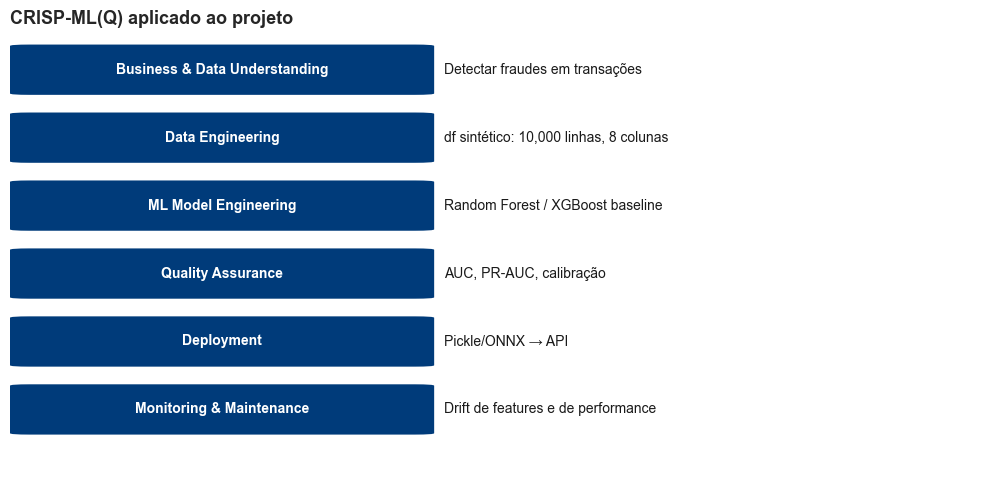

In [19]:
# [E1T2] Ciclo de vida do projeto (CRISP-ML(Q))
# Visualização do ciclo CRISP-ML(Q) aplicado ao nosso projeto
import matplotlib.patches as mpatches

fases = [
    ("Business & Data Understanding", "Detectar fraudes em transações"),
    ("Data Engineering",              f"df sintético: {len(df):,} linhas, {df.shape[1]} colunas"),
    ("ML Model Engineering",          "Random Forest / XGBoost baseline"),
    ("Quality Assurance",             "AUC, PR-AUC, calibração"),
    ("Deployment",                    "Pickle/ONNX → API"),
    ("Monitoring & Maintenance",      "Drift de features e de performance"),
]
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis("off")
for i, (fase, desc) in enumerate(fases):
    y = len(fases) - i
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.02, y - 0.4), 0.40, 0.7,
        boxstyle="round,pad=0.02", facecolor="#003B7A", edgecolor="none"
    ))
    ax.text(0.22, y - 0.05, fase, color="white", ha="center", va="center", fontsize=10, weight="bold")
    ax.text(0.45, y - 0.05, desc, color="#1A1A1A", ha="left", va="center", fontsize=10)
ax.set_xlim(0, 1); ax.set_ylim(0, len(fases) + 0.5)
plt.title("CRISP-ML(Q) aplicado ao projeto", loc="left", fontsize=13, weight="bold")
plt.tight_layout(); plt.show()


### Análise Exploratória de Dados (EDA) focada em modelagem.

Shape: (10000, 8)
Tipos: {'transacao_id': dtype('int64'), 'valor': dtype('float64'), 'hora': dtype('int64'), 'merchant_category': dtype('O'), 'device_type': dtype('O'), 'hist_compras_30d': dtype('int64'), 'tempo_conta_dias': dtype('int64'), 'fraude': dtype('int64')}

Proporção da classe positiva (fraude): 1.57%


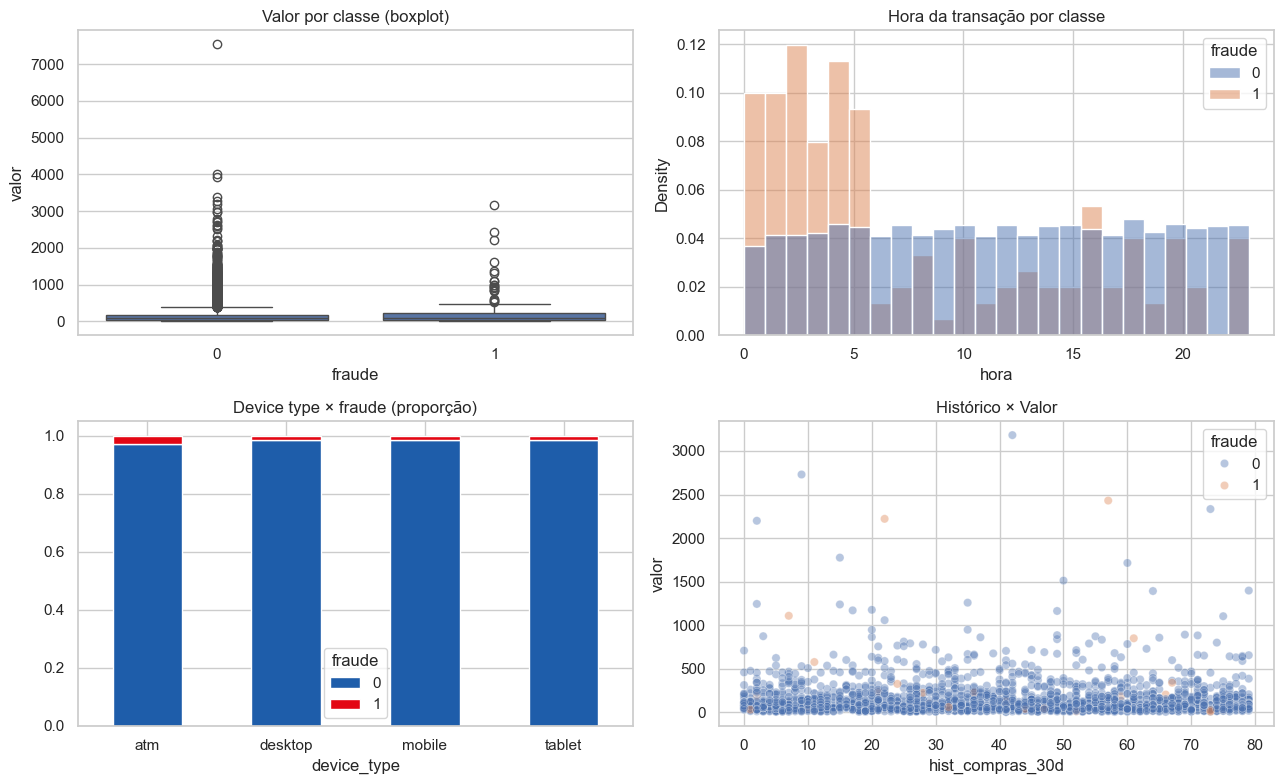

In [20]:
# [E1T3] Análise Exploratória de Dados (EDA) focada em modelagem
# Análise Exploratória focada em modelagem
print("Shape:", df.shape)
print("Tipos:", df.dtypes.to_dict())
print(f"\nProporção da classe positiva (fraude): {df['fraude'].mean():.2%}")

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
sns.boxplot(data=df, x='fraude', y='valor', ax=axes[0, 0])
axes[0, 0].set_title('Valor por classe (boxplot)')
sns.histplot(data=df, x='hora', hue='fraude', stat='density',
             common_norm=False, ax=axes[0, 1], bins=24)
axes[0, 1].set_title('Hora da transação por classe')
ctab = pd.crosstab(df['device_type'], df['fraude'], normalize='index')
ctab.plot(kind='bar', stacked=True, ax=axes[1, 0],
          color=['#1E5DAA', '#E30613'])
axes[1, 0].set_title('Device type × fraude (proporção)')
axes[1, 0].tick_params(axis='x', rotation=0)
sns.scatterplot(data=df.sample(min(2000, len(df)), random_state=SEED),
                x='hist_compras_30d', y='valor', hue='fraude',
                alpha=0.4, ax=axes[1, 1])
axes[1, 1].set_title('Histórico × Valor')
plt.tight_layout(); plt.show()


### 🧪 Exercício do Encontro 1

Aplique os conceitos vistos acima ao dataset `df`. Discuta os resultados com a turma antes de prosseguir para o próximo encontro.

## Encontro 2
**Data:** 15/05  •  **Horário:** 19:00 às 22:30

**Tópicos cobertos:**
- Engenharia de Atributos (Feature Engineering).
- Tratamento de dados em larga escala.
- Conceitos de Feature Store.

> 📖 **No documento `.md`:** seção *Encontro 2* contém a fundamentação teórica detalhada.

> 🎯 **Nos slides:** veja os slides do Encontro 2 para a apresentação em sala.

### Engenharia de Atributos (Feature Engineering).

In [21]:
# [E2T1] Engenharia de Atributos (Feature Engineering)
# Engenharia de atributos derivados
df['valor_log']      = np.log1p(df['valor'])
df['eh_madrugada']   = df['hora'].between(0, 5).astype(int)
df['ratio_compras']  = df['hist_compras_30d'] / (df['tempo_conta_dias'] + 1)
df['conta_nova']     = (df['tempo_conta_dias'] < 30).astype(int)

# One-hot encoding das categóricas
df_feat = pd.get_dummies(df, columns=['merchant_category', 'device_type'],
                         drop_first=True)

print(f"Colunas antes:  {df.shape[1]}")
print(f"Colunas depois: {df_feat.shape[1]}")
print("\nNovas features (head):")
df_feat[['valor_log', 'eh_madrugada', 'ratio_compras', 'conta_nova']].head()


Colunas antes:  12
Colunas depois: 18

Novas features (head):


,valor_log,eh_madrugada,ratio_compras,conta_nova
0,4.843084,0,0.036353,0
1,3.390136,0,0.008299,0
2,5.330349,0,0.066292,0
3,5.538554,1,0.001001,0
4,2.444952,0,0.047297,0


### Tratamento de dados em larga escala.

In [22]:
# [E2T2] Tratamento de dados em larga escala
# Simulação de processamento "em larga escala" via chunking com pandas.
# Em produção real: PySpark, Dask ou DuckDB sobre Parquet.
# Aqui usamos CSV + chunksize (não exige dependências extras como pyarrow).
from pathlib import Path

out_dir = Path('/tmp/transacoes_csv')
out_dir.mkdir(exist_ok=True)

# Particiona em arquivos por device_type (simulando arquivos diários/regionais)
for device, grupo in df.groupby('device_type'):
    grupo.to_csv(out_dir / f'device={device}.csv', index=False)

# Reler em chunks e agregar — padrão "stream processing" com pandas
CHUNK = 1_000
total_fraudes = 0
total_linhas  = 0
for arq in out_dir.glob('*.csv'):
    for pedaco in pd.read_csv(arq, chunksize=CHUNK):
        total_fraudes += int(pedaco['fraude'].sum())
        total_linhas  += len(pedaco)

print(f"Arquivos particionados em: {out_dir}")
print(f"Linhas processadas (em chunks de {CHUNK:,}): {total_linhas:,}")
print(f"Fraudes detectadas: {total_fraudes:,}  ({total_fraudes/total_linhas:.2%})")

# 💡 Em produção: substitua o CSV por Parquet (df.to_parquet, requer pyarrow)
#    — colunar, comprimido, ~5–10x menor e muito mais rápido para leituras seletivas.


Arquivos particionados em: /tmp/transacoes_csv
Linhas processadas (em chunks de 1,000): 10,000
Fraudes detectadas: 157  (1.57%)


### Conceitos de Feature Store.

In [23]:
# [E2T3] Conceitos de Feature Store
# Simulação simplificada de Feature Store em SQLite
# (em produção: Feast, Tecton, Vertex AI Feature Store, Databricks)
import sqlite3
from pathlib import Path

db_path = Path('/tmp/feature_store.db')
conn = sqlite3.connect(db_path)

# Tabela de features agregadas por cliente (offline store)
features_cliente = (
    df.groupby('tempo_conta_dias').agg(
        valor_medio    = ('valor', 'mean'),
        n_transacoes   = ('valor', 'count'),
        taxa_fraude    = ('fraude', 'mean'),
    ).reset_index()
)
features_cliente.to_sql('cliente_features', conn, if_exists='replace', index=False)

# Recuperação tipo "point-in-time lookup" (online store simulado)
def buscar_features(tempo_conta_dias: int) -> dict:
    cur = conn.cursor()
    cur.execute(
        "SELECT * FROM cliente_features WHERE tempo_conta_dias = ?",
        (tempo_conta_dias,),
    )
    cols = [d[0] for d in cur.description]
    row  = cur.fetchone()
    return dict(zip(cols, row)) if row else {}

print("Feature Store populado:", features_cliente.shape)
print("\nLookup exemplo (cliente com 500 dias de conta):")
print(buscar_features(500))
conn.close()


Feature Store populado: (2910, 4)

Lookup exemplo (cliente com 500 dias de conta):
{'tempo_conta_dias': 500, 'valor_medio': 35.305, 'n_transacoes': 2, 'taxa_fraude': 0.5}


### 🧪 Exercício do Encontro 2

Aplique os conceitos vistos acima ao dataset `df`. Discuta os resultados com a turma antes de prosseguir para o próximo encontro.

---

# Módulo 2 — Modelagem e Avaliação

## Encontro 3
**Data:** 21/05

**Tópicos cobertos:**
- Algoritmos de Classificação e Regressão.
- Métricas de avaliação (Matriz de Confusão, AUC-ROC, RMSE).

> 📖 **No documento `.md`:** seção *Encontro 3* contém a fundamentação teórica detalhada.

> 🎯 **Nos slides:** veja os slides do Encontro 3 para a apresentação em sala.

### Algoritmos de Classificação e Regressão.

In [24]:
# [E3T1] Algoritmos de Classificação e Regressão
# Baseline de classificação com Random Forest
from sklearn.model_selection import train_test_split
from sklearn.ensemble       import RandomForestClassifier
from sklearn.metrics        import classification_report, roc_auc_score

# Garante que df_feat existe (caso o aluno pule a célula anterior)
if 'df_feat' not in globals():
    df_feat = pd.get_dummies(df, columns=['merchant_category', 'device_type'],
                             drop_first=True)

X = df_feat.drop(columns=['transacao_id', 'fraude'])
y = df_feat['fraude']

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

clf = RandomForestClassifier(
    n_estimators=200, max_depth=8,
    class_weight='balanced', random_state=SEED, n_jobs=-1
)
clf.fit(X_tr, y_tr)

y_pred  = clf.predict(X_te)
y_proba = clf.predict_proba(X_te)[:, 1]
print(classification_report(y_te, y_pred, digits=3))
print(f"AUC-ROC: {roc_auc_score(y_te, y_proba):.3f}")


              precision    recall  f1-score   support

           0      0.988     0.926     0.956      1969
           1      0.052     0.258     0.087        31

    accuracy                          0.916      2000
   macro avg      0.520     0.592     0.521      2000
weighted avg      0.973     0.916     0.943      2000

AUC-ROC: 0.669


### Métricas de avaliação (Matriz de Confusão, AUC-ROC, RMSE).

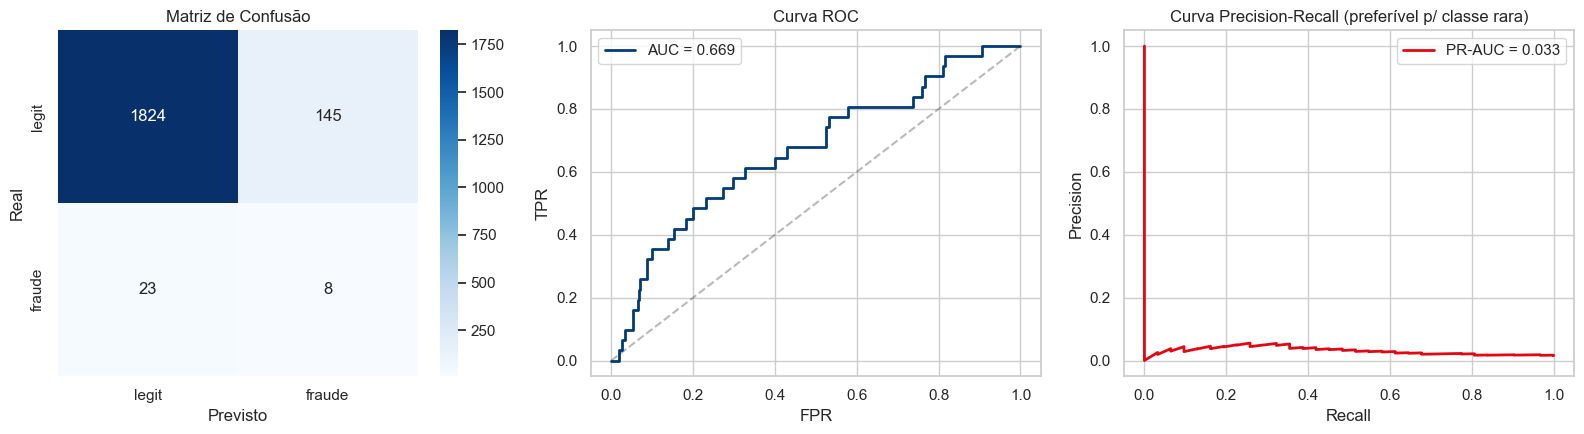

In [25]:
# [E3T2] Métricas de avaliação (Matriz de Confusão, AUC-ROC, RMSE)
# Painel de métricas — matriz de confusão + curva ROC + curva PR
from sklearn.metrics import (confusion_matrix, roc_curve,
                             precision_recall_curve, roc_auc_score,
                             average_precision_score)

cm    = confusion_matrix(y_te, y_pred)
fpr, tpr, _ = roc_curve(y_te, y_proba)
prec, rec, _ = precision_recall_curve(y_te, y_proba)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['legit', 'fraude'], yticklabels=['legit', 'fraude'])
axes[0].set_title('Matriz de Confusão')
axes[0].set_xlabel('Previsto'); axes[0].set_ylabel('Real')

axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_te, y_proba):.3f}',
             color='#003B7A', lw=2)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=.3)
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].legend()

axes[2].plot(rec, prec, label=f'PR-AUC = {average_precision_score(y_te, y_proba):.3f}',
             color='#E30613', lw=2)
axes[2].set_title('Curva Precision-Recall (preferível p/ classe rara)')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision'); axes[2].legend()
plt.tight_layout(); plt.show()


### 🧪 Exercício do Encontro 3

Aplique os conceitos vistos acima ao dataset `df`. Discuta os resultados com a turma antes de prosseguir para o próximo encontro.

## Encontro 4
**Data:** 22/05

**Tópicos cobertos:**
- Modelos de Agrupamento (Clustering).
- Validação Cruzada e Ajuste de Hiperparâmetros.

> 📖 **No documento `.md`:** seção *Encontro 4* contém a fundamentação teórica detalhada.

> 🎯 **Nos slides:** veja os slides do Encontro 4 para a apresentação em sala.

### Modelos de Agrupamento (Clustering).

/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/homebrew/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/homebrew/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.p

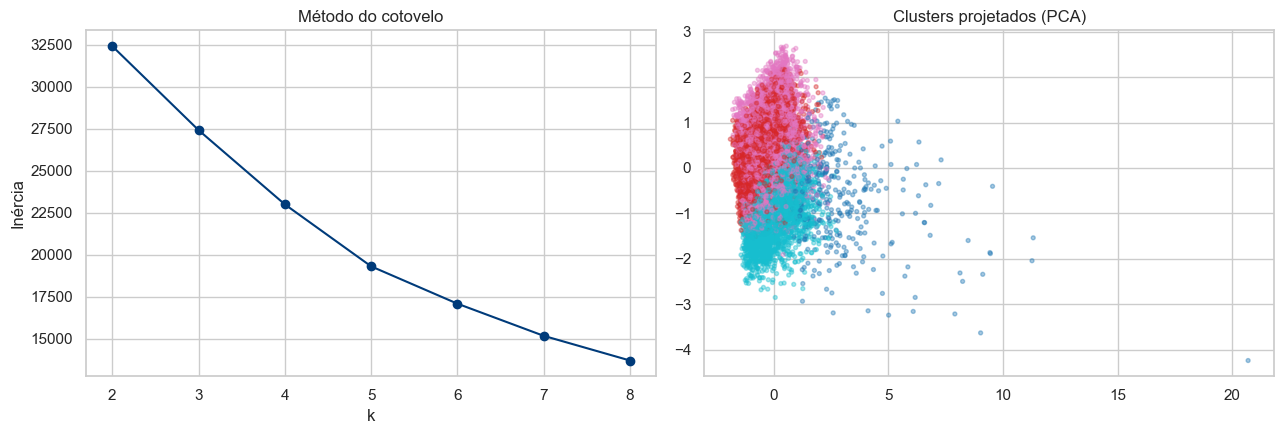


Média por cluster:


,valor,hora,hist_compras_30d,tempo_conta_dias,fraude
cluster,,,,,
0,1166.00,11.80,38.87,1353.35,0.05
1,124.15,6.98,60.78,1593.87,0.02
2,132.50,18.89,40.97,1521.66,0.01
3,133.29,7.60,17.82,1415.06,0.02


In [26]:
# [E4T1] Modelos de Agrupamento (Clustering)
# Clustering das transações (não-supervisionado)
from sklearn.cluster       import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

num_cols = ['valor', 'hora', 'hist_compras_30d', 'tempo_conta_dias']
X_num = StandardScaler().fit_transform(df[num_cols])

# Método do cotovelo
inercias = []
for k in range(2, 9):
    inercias.append(KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(X_num).inertia_)

# Treina com k=4 e projeta em 2D via PCA p/ visualizar
km = KMeans(n_clusters=4, random_state=SEED, n_init=10).fit(X_num)
df['cluster'] = km.labels_
X_2d = PCA(n_components=2, random_state=SEED).fit_transform(X_num)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(range(2, 9), inercias, marker='o', color='#003B7A')
axes[0].set_title('Método do cotovelo'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inércia')
sc = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=df['cluster'],
                     cmap='tab10', alpha=0.4, s=8)
axes[1].set_title('Clusters projetados (PCA)')
plt.tight_layout(); plt.show()

print("\nMédia por cluster:")
df.groupby('cluster')[num_cols + ['fraude']].mean().round(2)


### Validação Cruzada e Ajuste de Hiperparâmetros.

In [27]:
# [E4T2] Validação Cruzada e Ajuste de Hiperparâmetros
# Validação cruzada estratificada + tuning leve
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble        import RandomForestClassifier

if 'df_feat' not in globals():
    df_feat = pd.get_dummies(df, columns=['merchant_category', 'device_type'],
                             drop_first=True)
X = df_feat.drop(columns=['transacao_id', 'fraude'])
y = df_feat['fraude']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Baseline com CV
clf_base = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
scores = cross_val_score(clf_base, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"AUC CV (baseline): {scores.mean():.3f} ± {scores.std():.3f}")

# Tuning leve (grid pequeno para rodar em sala em < 1 min)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [6, 10, None],
}
gs = GridSearchCV(clf_base, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)
gs.fit(X, y)
print(f"\nMelhores hiperparâmetros: {gs.best_params_}")
print(f"AUC CV (tuned):    {gs.best_score_:.3f}")


AUC CV (baseline): 0.613 ± 0.030

Melhores hiperparâmetros: {'max_depth': 6, 'n_estimators': 200}
AUC CV (tuned):    0.692


### 🧪 Exercício do Encontro 4

Aplique os conceitos vistos acima ao dataset `df`. Discuta os resultados com a turma antes de prosseguir para o próximo encontro.

---

# Módulo 3 — Operacionalização (MLOps)

## Encontro 5
**Data:** 23/05  •  **Horário:** 08:00 às 12:00

**Tópicos cobertos:**
- Serialização de modelos (Pickle, ONNX).
- Estratégias de Deploy (Batch vs. Real-time).
- Monitoramento de Drifts e Re-treinamento automático.

> 📖 **No documento `.md`:** seção *Encontro 5* contém a fundamentação teórica detalhada.

> 🎯 **Nos slides:** veja os slides do Encontro 5 para a apresentação em sala.

### Serialização de modelos (Pickle, ONNX).

In [28]:
# [E5T1] Serialização de modelos (Pickle, ONNX)
# Serialização do modelo para deploy
import joblib
from pathlib import Path

# (Re)treina rápido caso 'clf' não esteja em memória
if 'clf' not in globals():
    from sklearn.ensemble       import RandomForestClassifier
    from sklearn.model_selection import train_test_split
    if 'df_feat' not in globals():
        df_feat = pd.get_dummies(df, columns=['merchant_category', 'device_type'],
                                 drop_first=True)
    X = df_feat.drop(columns=['transacao_id', 'fraude'])
    y = df_feat['fraude']
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=SEED
    )
    clf = RandomForestClassifier(n_estimators=100, max_depth=8,
                                 random_state=SEED, n_jobs=-1).fit(X_tr, y_tr)

# Salvar com joblib (preferido sobre pickle puro para sklearn)
out = Path('/tmp/modelo_fraude.joblib')
joblib.dump(clf, out)
print(f"Salvo: {out}  ({out.stat().st_size / 1024:.1f} KB)")

# Reload + sanity check
clf_loaded = joblib.load(out)
ok = (clf_loaded.predict(X_te.head(5)) == clf.predict(X_te.head(5))).all()
print(f"Sanity check predict idêntico: {ok}")

# Para ONNX (descomente em ambiente com skl2onnx):
# from skl2onnx import to_onnx
# onnx_model = to_onnx(clf, X_tr[:1].astype(np.float32))
# Path('/tmp/modelo_fraude.onnx').write_bytes(onnx_model.SerializeToString())


Salvo: /tmp/modelo_fraude.joblib  (2066.2 KB)
Sanity check predict idêntico: True


### Estratégias de Deploy (Batch vs. Real-time).

In [29]:
# [E5T2] Estratégias de Deploy (Batch vs. Real-time)
# Estratégias de deploy: batch vs real-time
# (a) Batch: aplicar modelo num lote inteiro e salvar resultados
df_batch = X_te.copy()
df_batch['score']      = clf.predict_proba(X_te)[:, 1]
df_batch['eh_fraude']  = (df_batch['score'] > 0.5).astype(int)
df_batch[['score', 'eh_fraude']].to_csv('/tmp/scores_batch.csv', index=False)
# Em produção: substitua por to_parquet (colunar, comprimido) — requer pyarrow.
print("Batch processado:", df_batch.shape)
print(df_batch[['score', 'eh_fraude']].head())

# (b) Real-time: função que serve uma transação por vez
def prever_transacao(payload: dict) -> dict:
    """Recebe dicionário com features da transação e devolve score + decisão."""
    linha = pd.DataFrame([payload]).reindex(columns=X_te.columns, fill_value=0)
    score = float(clf.predict_proba(linha)[0, 1])
    return {"score": round(score, 4), "eh_fraude": score > 0.5}

exemplo = X_te.iloc[0].to_dict()
print("\nPredição real-time:", prever_transacao(exemplo))


Batch processado: (2000, 18)
         score  eh_fraude
4804  0.147398          0
9421  0.199468          0
344   0.533494          1
7515  0.483419          0
5220  0.212861          0

Predição real-time: {'score': 0.1474, 'eh_fraude': False}


### Monitoramento de Drifts e Re-treinamento automático.

Drift de features (Kolmogorov-Smirnov):
  valor                     KS=0.049  p=0.0007  ⚠️ DRIFT
  hora                      KS=0.010  p=0.9940  ok
  hist_compras_30d          KS=0.014  p=0.9012  ok


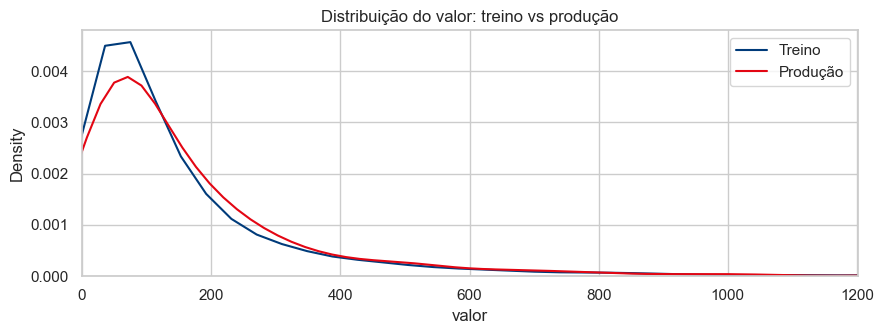

In [30]:
# [E5T3] Monitoramento de Drifts e Re-treinamento automático
# Detecção de drift de features (KS) e de performance
from scipy.stats import ks_2samp

# Simula dados de produção com leve drift no 'valor'
df_prod = df.sample(2000, random_state=99).copy()
df_prod['valor'] *= 1.15   # inflação simulada

print("Drift de features (Kolmogorov-Smirnov):")
for col in ['valor', 'hora', 'hist_compras_30d']:
    ks, p = ks_2samp(df[col], df_prod[col])
    flag = "⚠️ DRIFT" if p < 0.01 else "ok"
    print(f"  {col:24s}  KS={ks:.3f}  p={p:.4f}  {flag}")

# Visualização do drift no 'valor'
fig, ax = plt.subplots(figsize=(9, 3.5))
sns.kdeplot(df['valor'],      ax=ax, label='Treino',    color='#003B7A')
sns.kdeplot(df_prod['valor'], ax=ax, label='Produção',  color='#E30613')
ax.set_xlim(0, df['valor'].quantile(0.99))
ax.set_title('Distribuição do valor: treino vs produção')
ax.legend(); plt.tight_layout(); plt.show()


### 🧪 Exercício do Encontro 5

Aplique os conceitos vistos acima ao dataset `df`. Discuta os resultados com a turma antes de prosseguir para o próximo encontro.

---

## Encerramento

Este notebook acompanha o documento `.md` e a apresentação `.pptx` desta disciplina. Para revisar teoria, consulte o documento; para apresentar em sala, use os slides; para experimentar, fique aqui.

## Bibliografia

- GÉRON, Aurélien. *Mãos à Obra: Aprendizado de Máquina com Scikit-Learn, Keras & TensorFlow*.
- BURKOV, Andriy. *The Machine Learning Engineering Book*.